In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import json
from datetime import datetime, date, time, timedelta
import time as tm
from pathlib import Path
import matplotlib.pyplot as plt

In [129]:
xr_data = xr.open_dataset('jtest_00_out_03.nc')

In [36]:
xr_data

<xarray.Dataset> Size: 684MB
Dimensions:                             (timestamp: 277, ident: 5144)
Coordinates:
  * ident                               (ident) object 41kB 'A' 'AA' ... 'ZYXI'
  * timestamp                           (timestamp) datetime64[ns] 2kB 2025-0...
Data variables: (12/60)
    quote.askTime                       (timestamp, ident) object 11MB ...
    quote.bidTime                       (timestamp, ident) object 11MB ...
    quote.quoteTime                     (timestamp, ident) object 11MB ...
    quote.tradeTime                     (timestamp, ident) object 11MB ...
    regular.regularMarketTradeTime      (timestamp, ident) object 11MB ...
    extended.quoteTime                  (timestamp, ident) object 11MB ...
    ...                                  ...
    reference.htbRate                   (timestamp, ident) float64 11MB ...
    regular.regularMarketLastPrice      (timestamp, ident) float64 11MB ...
    regular.regularMarketLastSize       (timestamp, ident) float64 11MB ...
    regular.regularMarketNetChange      (timestamp, ident) float64 11MB ...
    regular.regularMarketPercentChange  (timestamp, ident) float64 11MB ...
    reference.htbQuantity               (timestamp, ident) float64 11MB ...

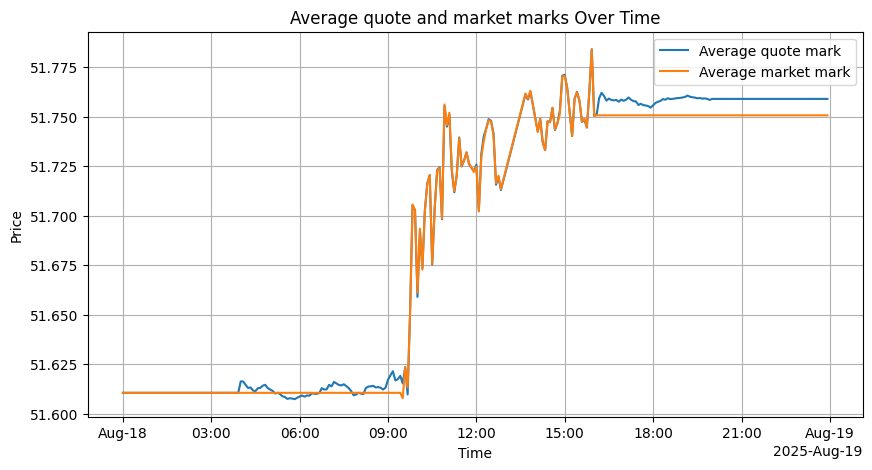

In [128]:
# Compute mean across ident dimension

# Extract just the time portion
times = xr_data['timestamp'].dt.time

# Define cutoff
start = pd.to_datetime("00:00").time()
end = pd.to_datetime("03:55").time()
start2 = pd.to_datetime("20:05").time()
end2 = pd.to_datetime("23:55").time()

# Mask by time range
mask = ((times >= start) & (times <= end)) | ((times >= start2) & (times <= end2))

# Apply both masks: time AND value != 0
avg_e_mark = (
    xr_data['extended.mark']
    .where(mask)                # keep only in time windows
    .where(xr_data['extended.mark'] != 0)  # drop zeros
    .mean(dim='ident')
)

#avg_e_mark = (xr_data['extended.mark'].where(mask, drop=True).mean(dim='ident') )
avg_q_mark = (
    xr_data['quote.mark']
    .where(xr_data['quote.mark'] != 0)
    .mean(dim='ident')
)
avg_m_mark = xr_data['regular.regularMarketLastPrice'].mean(dim='ident')

# Plot over time
plt.figure(figsize=(10,5))
#avg_e_mark.plot(label='Average htbRate')
avg_q_mark.plot(label='Average quote mark')
avg_m_mark.plot(label='Average market mark')

plt.title("Average quote and market marks Over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

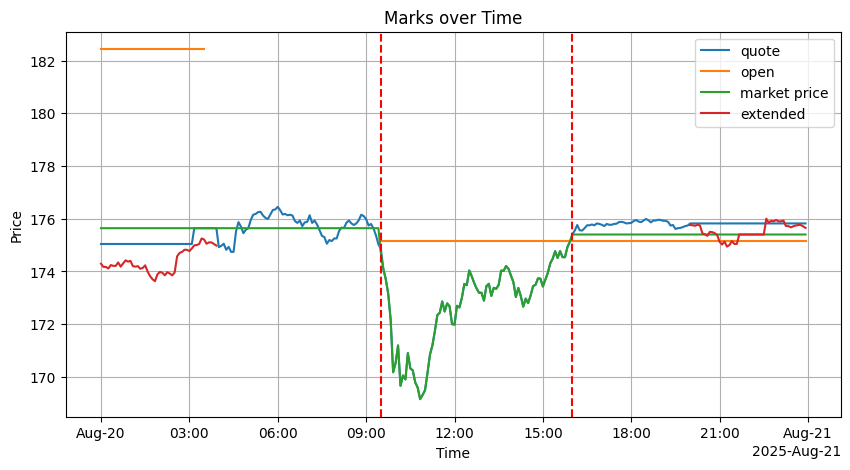

In [238]:
aapl_marks = xr_data['quote.mark'].sel(ident='NVDA')
aapl_marks_markets = xr_data['regular.regularMarketLastPrice'].sel(ident='NVDA')
aapl_open = xr_data['quote.openPrice'].sel(ident='NVDA')
aapl_open_droped = aapl_open.where(aapl_open != 0)
aapl_e_mark = xr_data['extended.mark'].sel(ident='NVDA').where(xr_data['extended.mark'].sel(ident='NVDA') != 0)
aapl_high = xr_data['quote.52WeekHigh'].sel(ident='NVDA').where(xr_data['quote.52WeekHigh'].sel(ident='NVDA') != 0)

plt.figure(figsize=(10,5))
aapl_marks.plot(label='quote')
aapl_open_droped.plot(label='open')
aapl_marks_markets.plot(label='market price')
aapl_e_mark.plot(label='extended')
# aapl_high.plot(label='high')

plt.title("Marks over Time")
plt.xlabel("Time")
plt.ylabel("Price")
plt.axvline(x=np.datetime64('2025-08-20T16:00'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-20T09:30'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

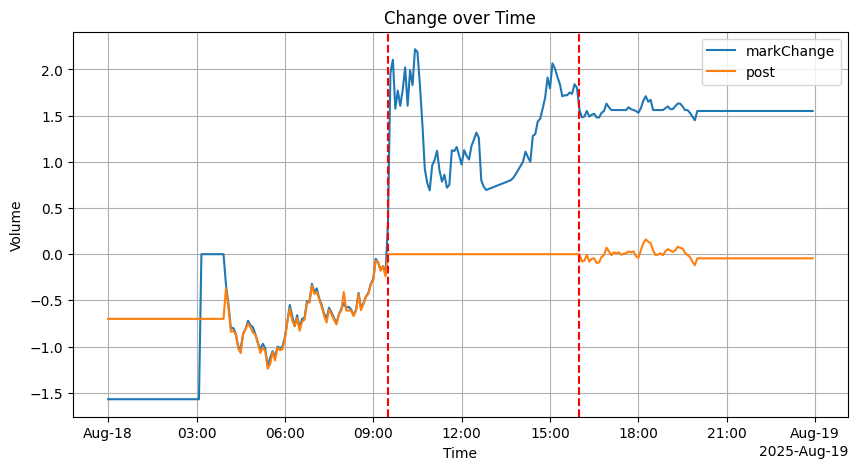

In [96]:
aapl_markC = xr_data['quote.markChange'].sel(ident='NVDA')
aapl_postmarkC = xr_data['quote.postMarketChange'].sel(ident='NVDA')

plt.figure(figsize=(10,5))
aapl_markC.plot(label='markChange')
aapl_postmarkC.plot(label='post')

plt.title("Change over Time")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.axvline(x=np.datetime64('2025-08-18T09:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-18T16:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

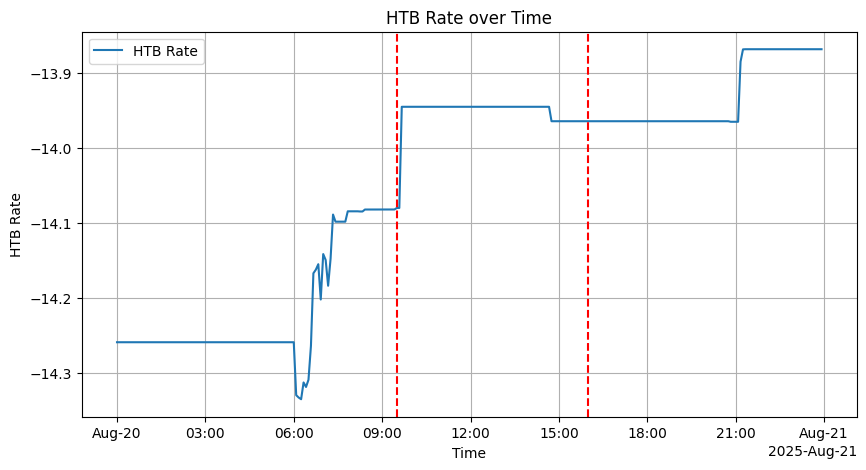

In [150]:
avg_htb = xr_data['reference.htbRate'].mean(dim='ident')

plt.figure(figsize=(10,5))
avg_htb.plot(label='HTB Rate')

plt.title("HTB Rate over Time")
plt.xlabel("Time")
plt.ylabel("HTB Rate")
plt.axvline(x=np.datetime64('2025-08-20T09:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-20T16:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

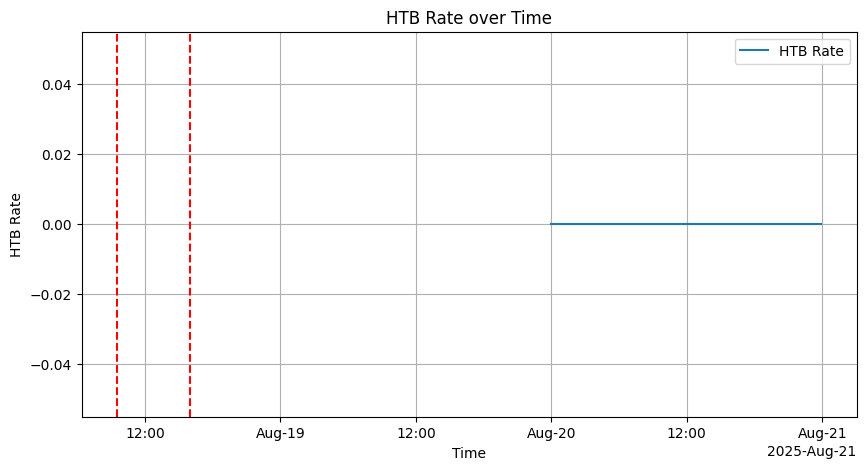

In [181]:
extened_total_volume = xr_data['extended.totalVolume'].mean(dim='ident')

plt.figure(figsize=(10,5))
extened_total_volume.plot(label='HTB Rate')

plt.title("HTB Rate over Time")
plt.xlabel("Time")
plt.ylabel("HTB Rate")
plt.axvline(x=np.datetime64('2025-08-18T09:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-18T16:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

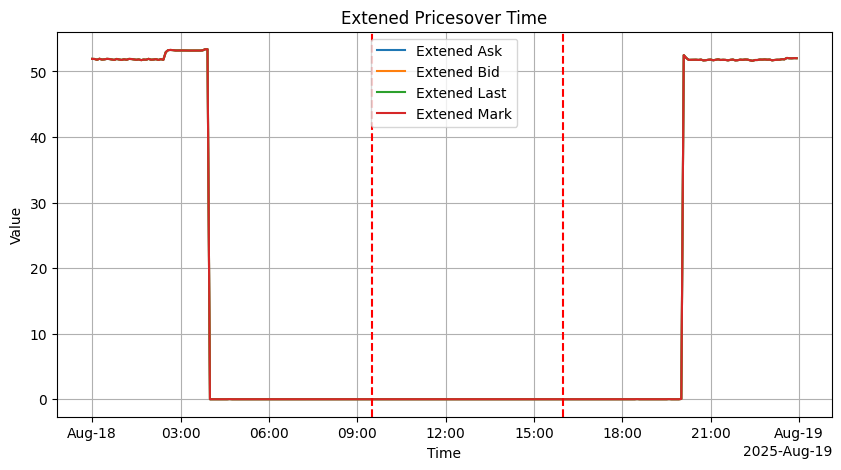

In [103]:
extened_ask = xr_data['extended.askPrice'].mean(dim='ident')
extened_bid = xr_data['extended.askPrice'].mean(dim='ident')
extened_last = xr_data['extended.askPrice'].mean(dim='ident')
extened_mark = xr_data['extended.askPrice'].mean(dim='ident')

plt.figure(figsize=(10,5))
extened_ask.plot(label='Extened Ask')
extened_bid.plot(label='Extened Bid')
extened_last.plot(label='Extened Last')
extened_mark.plot(label='Extened Mark')

plt.title("Extened Pricesover Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.axvline(x=np.datetime64('2025-08-18T09:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-18T16:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

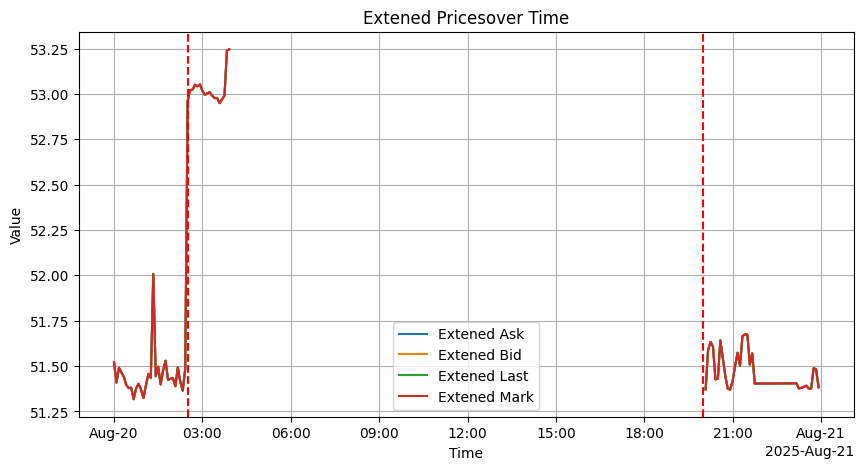

In [135]:
times = xr_data['timestamp'].dt.time

start = pd.to_datetime("00:00").time()
end = pd.to_datetime("03:55").time()
start2 = pd.to_datetime("20:05").time()
end2 = pd.to_datetime("23:55").time()

mask = ((times >= start) & (times <= end)) | ((times >= start2) & (times <= end2))

extened_ask = xr_data['extended.askPrice'].where(mask).mean(dim='ident')
extened_bid = xr_data['extended.askPrice'].where(mask).mean(dim='ident')
extened_last = xr_data['extended.askPrice'].where(mask).mean(dim='ident')
extened_mark = xr_data['extended.askPrice'].where(mask).mean(dim='ident')

plt.figure(figsize=(10,5))
extened_ask.plot(label='Extened Ask')
extened_bid.plot(label='Extened Bid')
extened_last.plot(label='Extened Last')
extened_mark.plot(label='Extened Mark')

plt.title("Extened Pricesover Time")
plt.xlabel("Time")
plt.ylabel("Value")
plt.axvline(x=np.datetime64('2025-08-20T02:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-20T20:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

In [141]:
xr_data['extended.askPrice'].mean(dim='ident').sel(timestamp=np.datetime64('2025-08-20T02:25'), method="nearest")

<xarray.DataArray 'extended.askPrice' ()> Size: 8B
array(51.48427674)
Coordinates:
    timestamp  datetime64[ns] 8B 2025-08-20T02:25:00

In [147]:
htb = xr_data['reference.htbRate']

# Previous value
prev = htb.shift(timestamp=1)

# Detect changes
changes = htb != prev

# Extract only change points
df_changes = (
    xr.Dataset({
        "from_htbRate": prev,
        "to_htbRate": htb
    })
    .where(changes)                        # keep only change rows
    .to_dataframe()
    .dropna()
    .reset_index()
)

print(df_changes.head(-# Unique change times across all idents
unique_times = df_changes['timestamp'].drop_duplicates().sort_values().reset_index(drop=True)

print(unique_times)
20))  # nice preview
print(df_changes.count())

               timestamp  ident  from_htbRate  to_htbRate
0    2025-08-20 06:05:00   AAME         -1.50       -0.75
1    2025-08-20 06:05:00    ABP        -19.75      -20.75
2    2025-08-20 06:05:00   ABSI         -1.50       -1.00
3    2025-08-20 06:05:00   ABVE       -743.50     -753.25
4    2025-08-20 06:05:00   AIRO        -34.50      -36.00
...                  ...    ...           ...         ...
1478 2025-08-20 21:10:00   RAVE         -4.00        0.00
1479 2025-08-20 21:10:00   RAYA        -11.25      -14.00
1480 2025-08-20 21:10:00    RCC        -46.75      -51.50
1481 2025-08-20 21:10:00  REGCP         -0.25       -0.50
1482 2025-08-20 21:10:00   RENT         -3.25       -4.25

[1483 rows x 4 columns]
timestamp       1503
ident           1503
from_htbRate    1503
to_htbRate      1503
dtype: int64


In [148]:
# Unique change times across all idents
unique_times = df_changes['timestamp'].drop_duplicates().sort_values().reset_index(drop=True)

print(unique_times)


0    2025-08-20 06:05:00
1    2025-08-20 06:10:00
2    2025-08-20 06:15:00
3    2025-08-20 06:20:00
4    2025-08-20 06:25:00
5    2025-08-20 06:30:00
6    2025-08-20 06:35:00
7    2025-08-20 06:40:00
8    2025-08-20 06:45:00
9    2025-08-20 06:50:00
10   2025-08-20 06:55:00
11   2025-08-20 07:00:00
12   2025-08-20 07:05:00
13   2025-08-20 07:10:00
14   2025-08-20 07:15:00
15   2025-08-20 07:20:00
16   2025-08-20 07:25:00
17   2025-08-20 08:15:00
18   2025-08-20 09:30:00
19   2025-08-20 20:50:00
20   2025-08-20 21:10:00
21   2025-08-20 21:15:00
22   2025-08-20 21:20:00
Name: timestamp, dtype: datetime64[ns]


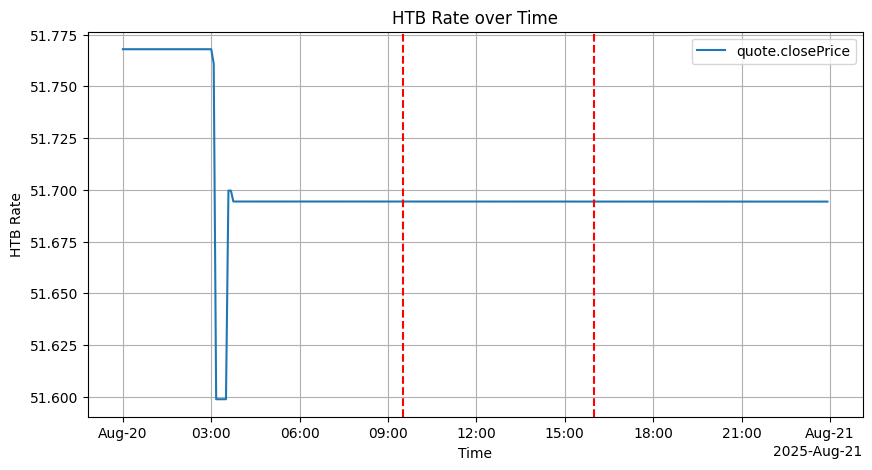

In [228]:
stat1 = 'quote.closePrice'
stat2 = 'quote.totalVolume'

# convert each datetime to seconds since epoch
timestamps = xr.apply_ufunc(
    lambda x: x.astype("datetime64[s]").astype(np.int64), 
    xr_data[stat1]
)

# take the mean over ident
mean_timestamps = timestamps.mean(dim="ident")

# convert back to datetime
stat1_data = mean_timestamps.astype("datetime64[s]")

stat1_data = xr_data[stat1].mean(dim='ident')
stat2_data = xr_data[stat2].mean(dim='ident')

plt.figure(figsize=(10,5))
stat1_data.plot(label=stat1)
# stat2_data.plot(label=stat2)

plt.title("HTB Rate over Time")
plt.xlabel("Time")
plt.ylabel("HTB Rate")
plt.axvline(x=np.datetime64('2025-08-20T09:30'),color='red',linestyle='--')
plt.axvline(x=np.datetime64('2025-08-20T16:00'),color='red',linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

In [231]:
xr_data['quote.closePrice'].mean(dim='ident').sel(timestamp=np.datetime64('2025-08-20T03:50'), method="nearest")

<xarray.DataArray 'quote.closePrice' ()> Size: 8B
array(51.69432223)
Coordinates:
    timestamp  datetime64[ns] 8B 2025-08-20T03:50:00